# Week 5 - Support Vector Machines

In [2]:
#pip install pandas numpy scikit-learn matplotlib seaborn kagglehub

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import kagglehub

from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

print("All imports successful.")

All imports successful.


## 1. Data Loading & Cleaning

In [4]:
#Load from Kaggle
path = kagglehub.dataset_download("laotse/credit-risk-dataset")
df = pd.read_csv(f"{path}/credit_risk_dataset.csv")

print(f"Raw shape: {df.shape}")

#Cleaning
df = df.drop_duplicates()

# Median imputation for employment length (right-skewed, so median > mean here)
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

# Grade-matched median for interest rate - preserves credit-grade logic
df['loan_int_rate'] = df['loan_int_rate'].fillna(
    df.groupby('loan_grade')['loan_int_rate'].transform('median')
)

# Remove logical impossibilities (not just statistical outliers)
df = df[df['person_emp_length'] <= df['person_age']]
df = df[df['person_age'] <= 100]
df = df[df['person_emp_length'] <= 60]

print(f"Clean shape: {df.shape}")
print(f"Default rate (loan_status=1): {df['loan_status'].mean()*100:.2f}%")
print(f"\nColumn types:\n{df.dtypes}")

Raw shape: (32581, 12)
Clean shape: (32409, 12)
Default rate (loan_status=1): 21.87%

Column types:
person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object


---
## 2. Setup: Classification Target, Subsample, and Scaling

In [5]:
numeric_features = ['person_income', 'person_age', 'person_emp_length',
                    'loan_amnt', 'loan_percent_income', 'loan_int_rate']
categorical_features = ['loan_intent', 'loan_grade',
                        'person_home_ownership', 'cb_person_default_on_file']

X = df[numeric_features + categorical_features].copy()
y = df['loan_status'].copy()
mask = X.notna().all(axis=1)
X, y = X[mask], y[mask]

# Stratified subsample: kernel SVM training cost grows ~O(n^2), so we cap n for tractability
# while preserving the ~20% default rate. The linear logistic model in Week 4 used the full
# set; here we trade a little data for the ability to fit several kernels and sweep C/gamma.
SUBSAMPLE = 6000
if len(X) > SUBSAMPLE:
    from sklearn.model_selection import train_test_split as _tts
    X, _, y, _ = _tts(X, y, train_size=SUBSAMPLE, random_state=42, stratify=y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# SVMs are acutely scale-sensitive: an unscaled large-magnitude feature dominates the
# distance metric. Scaling is mandatory here, not optional.
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

print(f"Working sample: {len(X):,} loans | default rate: {y.mean()*100:.1f}%")
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print()
print("Interpretation: We deliberately shrink the data so kernel SVMs are affordable. If a")
print("kernel SVM beats Week 4's logistic AUC even on this smaller sample, that is strong")
print("evidence the decision boundary is genuinely non-linear and worth the extra compute.")

Working sample: 6,000 loans | default rate: 21.9%
Train: 4,500 | Test: 1,500

Interpretation: We deliberately shrink the data so kernel SVMs are affordable. If a
kernel SVM beats Week 4's logistic AUC even on this smaller sample, that is strong
evidence the decision boundary is genuinely non-linear and worth the extra compute.


## 3. Linear SVM: The Maximum-Margin Hyperplane

In [6]:
# A linear SVM finds the separating hyperplane with the WIDEST margin to the nearest
# points (the support vectors). class_weight balances the minority default class.
lin_svm = Pipeline([
    ('prep', preprocessor),
    ('svm', SVC(kernel='linear', C=1.0, class_weight='balanced', probability=True,
                random_state=42))
])
lin_svm.fit(X_train, y_train)
proba_lin = lin_svm.predict_proba(X_test)[:, 1]
preds_lin = lin_svm.predict(X_test)
auc_lin = roc_auc_score(y_test, proba_lin)

n_sv = lin_svm.named_steps['svm'].n_support_
print("Linear SVM")
print(f"  Test AUC: {auc_lin:.4f}")
print(f"  Support vectors: {n_sv.sum():,} of {len(X_train):,} training points "
      f"({n_sv.sum()/len(X_train)*100:.1f}%)")
print()
print(classification_report(y_test, preds_lin, target_names=['Repaid', 'Default']))
print("Interpretation: Only the support vectors - the borderline cases nearest the boundary -")
print("define the model; the rest of the data could vanish without changing it. A large support")
print("fraction signals classes that overlap heavily, which is exactly what we expect in credit")
print("risk where 'safe' and 'risky' borrowers are not cleanly separable.")

Linear SVM
  Test AUC: 0.8777
  Support vectors: 2,185 of 4,500 training points (48.6%)

              precision    recall  f1-score   support

      Repaid       0.93      0.84      0.88      1172
     Default       0.57      0.77      0.66       328

    accuracy                           0.82      1500
   macro avg       0.75      0.81      0.77      1500
weighted avg       0.85      0.82      0.83      1500

Interpretation: Only the support vectors - the borderline cases nearest the boundary -
define the model; the rest of the data could vanish without changing it. A large support
fraction signals classes that overlap heavily, which is exactly what we expect in credit
risk where 'safe' and 'risky' borrowers are not cleanly separable.


---
## 4. The Kernel Trick: RBF and Polynomial Boundaries

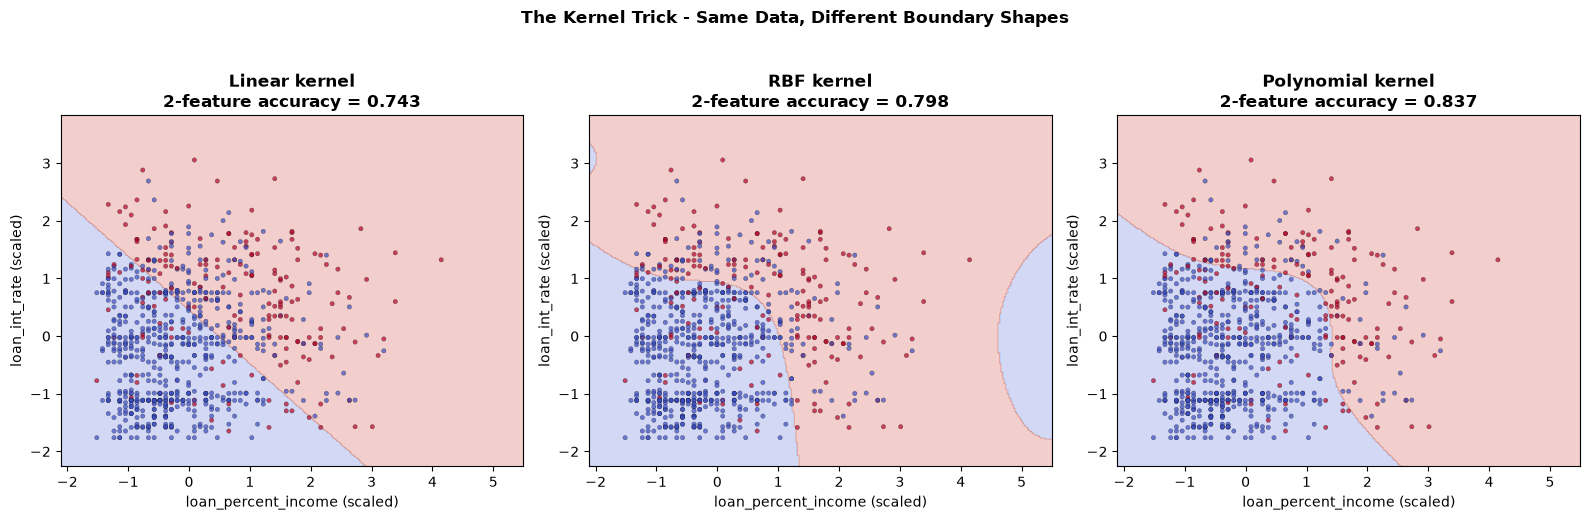

Interpretation: The linear kernel can only draw a straight line; RBF wraps flexible,
local pockets around clusters of defaulters; polynomial bends smoothly. On just two
features the gains are modest, but this is the visual intuition for WHY a kernel might
help - and the warning that RBF's flexibility can overfit if gamma is too large (next).


In [7]:
# The kernel trick computes similarities in a high-dimensional space WITHOUT ever building
# the coordinates there - letting a 'linear' separator become a curved boundary in our space.
# We visualize on two features so the boundary is actually drawable.
viz_feats = ['loan_percent_income', 'loan_int_rate']
Xv = X[viz_feats].values
sc_v = StandardScaler().fit(Xv)
Xv_s = sc_v.transform(Xv)
Xv_tr, Xv_te, yv_tr, yv_te = train_test_split(
    Xv_s, y.values, test_size=0.25, random_state=42, stratify=y)

kernels = [
    ('Linear',     SVC(kernel='linear', C=1.0, class_weight='balanced')),
    ('RBF',        SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced')),
    ('Polynomial', SVC(kernel='poly', degree=3, C=1.0, gamma='scale', class_weight='balanced')),
]

xx, yy = np.meshgrid(
    np.linspace(Xv_s[:, 0].min()-0.5, Xv_s[:, 0].max()+0.5, 300),
    np.linspace(Xv_s[:, 1].min()-0.5, Xv_s[:, 1].max()+0.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, model) in zip(axes, kernels):
    model.fit(Xv_tr, yv_tr)
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    samp = np.random.default_rng(42).choice(len(Xv_te), min(800, len(Xv_te)), replace=False)
    ax.scatter(Xv_te[samp, 0], Xv_te[samp, 1], c=yv_te[samp], cmap='coolwarm',
               s=10, edgecolor='k', linewidth=0.2, alpha=0.7)
    acc = (model.predict(Xv_te) == yv_te).mean()
    ax.set_title(f'{name} kernel\n2-feature accuracy = {acc:.3f}', fontweight='bold')
    ax.set_xlabel('loan_percent_income (scaled)')
    ax.set_ylabel('loan_int_rate (scaled)')
plt.suptitle('The Kernel Trick - Same Data, Different Boundary Shapes', fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("Interpretation: The linear kernel can only draw a straight line; RBF wraps flexible,")
print("local pockets around clusters of defaulters; polynomial bends smoothly. On just two")
print("features the gains are modest, but this is the visual intuition for WHY a kernel might")
print("help - and the warning that RBF's flexibility can overfit if gamma is too large (next).")

## 5. Regularization for SVMs: the C and gamma Dials

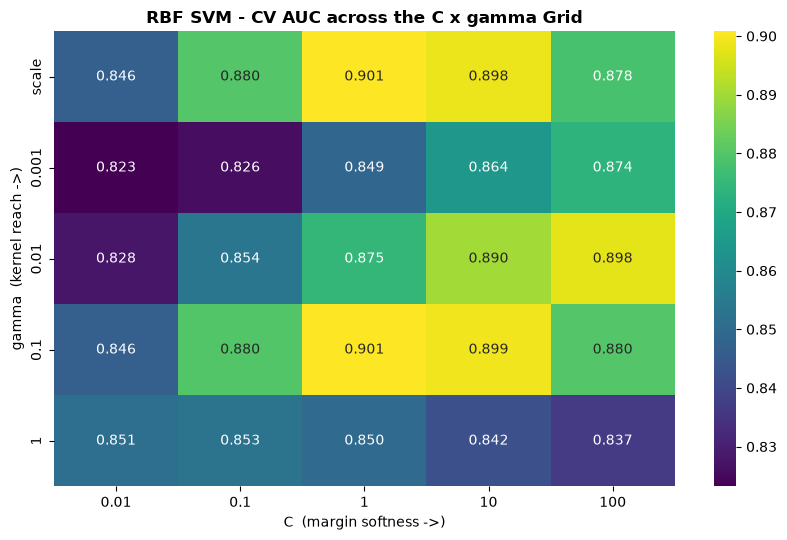

Best RBF config: C=1, gamma=scale, CV AUC=0.9008

Interpretation: The heatmap is a bias-variance map you can read at a glance. The bottom-
right corner (large C, large gamma) is the overfitting danger zone - high training fit,
worse CV. The sweet spot sits in the interior, where the margin is soft enough to
generalize. This is the SVM analogue of choosing alpha in Week 2 and C in Week 4.


In [8]:
# C  = margin softness. Small C -> wide, tolerant margin (more bias, less variance).
#                        Large C -> the model fights to classify every point (the reverse).
# gamma = RBF reach. Small gamma -> smooth, far-reaching influence (more bias).
#                    Large gamma -> tight, local bumps that can memorize noise (more variance).
# We sweep both with full-feature RBF SVMs, scored by 5-fold CV AUC.
rbf_base = Pipeline([('prep', preprocessor),
                     ('svm', SVC(kernel='rbf', class_weight='balanced'))])

Cs = [0.01, 0.1, 1, 10, 100]
gammas = ['scale', 0.001, 0.01, 0.1, 1]
heat = np.zeros((len(gammas), len(Cs)))
for i, g in enumerate(gammas):
    for j, C in enumerate(Cs):
        rbf_base.set_params(svm__C=C, svm__gamma=g)
        heat[i, j] = cross_val_score(rbf_base, X_train, y_train, cv=4,
                                     scoring='roc_auc').mean()

fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.heatmap(heat, annot=True, fmt='.3f', cmap='viridis',
            xticklabels=[str(c) for c in Cs],
            yticklabels=[str(g) for g in gammas], ax=ax)
ax.set_xlabel('C  (margin softness ->)')
ax.set_ylabel('gamma  (kernel reach ->)')
ax.set_title('RBF SVM - CV AUC across the C x gamma Grid', fontweight='bold')
plt.tight_layout()
plt.show()

bi, bj = np.unravel_index(np.argmax(heat), heat.shape)
best_C, best_g = Cs[bj], gammas[bi]
print(f"Best RBF config: C={best_C}, gamma={best_g}, CV AUC={heat[bi, bj]:.4f}")
print()
print("Interpretation: The heatmap is a bias-variance map you can read at a glance. The bottom-")
print("right corner (large C, large gamma) is the overfitting danger zone - high training fit,")
print("worse CV. The sweet spot sits in the interior, where the margin is soft enough to")
print("generalize. This is the SVM analogue of choosing alpha in Week 2 and C in Week 4.")

---
## 6. Kernel Comparison (Full Features) and Verdict vs Week 4

          Model  Test AUC  CV AUC
 Polynomial SVM    0.9174  0.8932
RBF SVM (tuned)    0.9144  0.9008
     Linear SVM    0.8777  0.8612


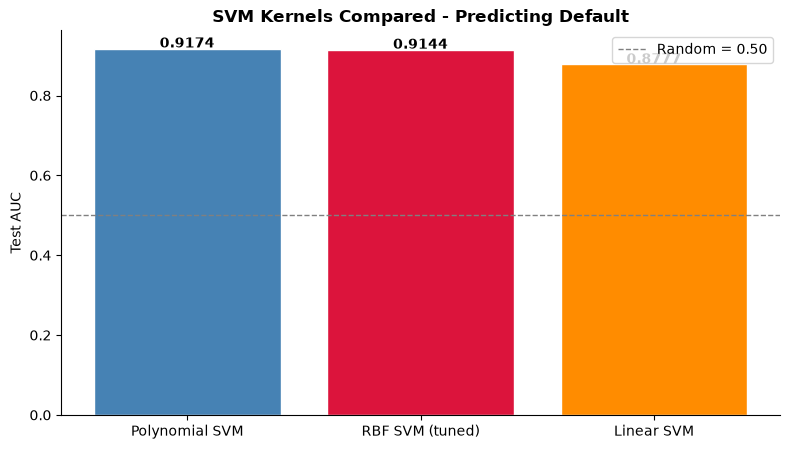


What this means for the Chief Risk Officer: if the tuned RBF SVM only ties the linear
SVM (and Week 4's logistic AUC), the honest read is that the default boundary is close
to linear - and we should prefer the simpler, faster, more interpretable model. SVMs
earn their cost only when the kernel clearly outperforms; complexity must pay rent.


In [9]:
# Fit each kernel on ALL features with the tuned RBF settings, compare on the test set.
models = {
    'Linear SVM': SVC(kernel='linear', C=1.0, class_weight='balanced',
                      probability=True, random_state=42),
    'RBF SVM (tuned)': SVC(kernel='rbf', C=best_C, gamma=best_g, class_weight='balanced',
                           probability=True, random_state=42),
    'Polynomial SVM': SVC(kernel='poly', degree=3, C=1.0, gamma='scale',
                          class_weight='balanced', probability=True, random_state=42),
}
rows = []
for name, m in models.items():
    pipe = Pipeline([('prep', preprocessor), ('svm', m)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=4, scoring='roc_auc').mean()
    rows.append({'Model': name,
                 'Test AUC': round(roc_auc_score(y_test, proba), 4),
                 'CV AUC': round(cv_auc, 4)})
res = pd.DataFrame(rows).sort_values('Test AUC', ascending=False)
print(res.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.6))
colors = ['steelblue', 'crimson', 'darkorange']
ax.bar(res['Model'], res['Test AUC'], color=colors, edgecolor='white')
for i, v in enumerate(res['Test AUC']):
    ax.text(i, v + 0.003, f'{v:.4f}', ha='center', fontweight='bold')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Random = 0.50')
ax.set_ylabel('Test AUC')
ax.set_title('SVM Kernels Compared - Predicting Default', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print()
print("What this means for the Chief Risk Officer: if the tuned RBF SVM only ties the linear")
print("SVM (and Week 4's logistic AUC), the honest read is that the default boundary is close")
print("to linear - and we should prefer the simpler, faster, more interpretable model. SVMs")
print("earn their cost only when the kernel clearly outperforms; complexity must pay rent.")

### Week 5 Takeaways and the Final Model Family

**What this week established:**
- The **linear SVM** maximizes the margin; only the **support vectors** (borderline cases)
  define it, and a large support fraction confirms heavily overlapping classes in credit risk.
- The **kernel trick** lets RBF and polynomial kernels draw curved boundaries cheaply; the
  2-feature visualization makes the intuition concrete.
- **C and gamma** are the SVM's regularization dials, and the C x gamma AUC heatmap is a
  readable bias-variance map - the direct analogue of Week 2's alpha and Week 4's C.
- The verdict is decided by whether a tuned kernel *clearly* beats the linear baseline; if it
  only ties, parsimony wins.

**The final model family:** SVMs gave us flexible but opaque boundaries. **Week 6** turns to
decision trees and random forests, which are non-linear in a completely different way -
axis-aligned splits that are easy to read, then averaged across many trees for stability and
strong out-of-the-box accuracy. Week 6 also closes the capstone loop with a single leaderboard
ranking every classifier - logistic, SVM, tree, and forest - on the same held-out test set.